# Evaluación de clasificadores . Derecho a las Víctimas

## ¿Qué hace este notebook?

Compara las predicciones de cualquier clasificador contra las etiquetas reales del test set y muestra:

- Métricas principales (Accuracy, F1, Precision, Recall, Kappa)
- Matriz de confusión
- Análisis de errores 

**Para evaluar un clasificador nuevo:** se cambian las rutas en la Sección 1 y se corren todas las celdas 


### Nota sobre las métricas

La métrica principal es **F1 macro**, no Accuracy, porque las clases están desbalanceadas (más negativos que positivos). Además para Kappa el criterio es el siguiente:

| Kappa     | Interpretación   |
| < 0.0     | Peor que el azar |
| 0.0 – 0.2 | Leve             |
| 0.2 – 0.4 | Débil            |
| 0.4 – 0.6 | Moderado         |
| 0.6 – 0.8 | Bueno            | 
| > 0.8     | Excelente        |

> **Observación:** los falsos negativos (predijo NO, era SÍ) son más costosos que los falsos positivos en este dominio, porque perder una norma de derechos de víctimas es peor que incluir una de más.

## 1. Configuración

**Solo modificar esta sección para evaluar un clasificador nuevo.**

In [1]:
#  Archivo con las predicciones del clasificador a evaluar 
# Debe tener columnas: 'Número' y 'caso_ok' (la predicción)
# Opcionalmente: 'Justificación' para el análisis de errores
FILE_PREDICCIONES  = 'resultado_ollama3.1_p3_resumen.xlsx'

# Nombre del clasificador (aparece en los gráficos y tablas)
NOMBRE_CLASIFICADOR = 'Ollama (llama3.1:8b)'
# Archivo original con las etiquetas reales
FILE_ORIGINAL = 'Normativa_nacional_víctimas_1869-2023.xlsx'

#Archivo test con las etiquetas originales 
FILE_TEST_ETIQUETAS =  'test_con_etiqueta.xlsx'

# Parámetros del split
TEST_SIZE    = 0.30
RANDOM_STATE = 42

## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, cohen_kappa_score
)
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


## 3. Carga y merge de datos

In [3]:
df_pred = pd.read_excel(FILE_PREDICCIONES)
df_test = pd.read_excel(FILE_TEST_ETIQUETAS)
df_pred['Número'] = df_pred['Número'].astype(str).str.strip()
df_test['Número'] = df_test['Número'].astype(str).str.strip()

merged = df_pred.merge(
    df_test[['Número', 'caso_ok']],
    on='Número',
    suffixes=('_pred', '_real')
)
merged = merged[merged['caso_ok_pred'] != -1]
n = len(merged)

y_pred = merged['caso_ok_pred']
y_real = merged['caso_ok_real']

## 4. Métricas

In [5]:
# Tabla de métricas
metricas = {
    'Accuracy':              round(accuracy_score(y_real, y_pred), 3),
    'F1 macro':            round(f1_score(y_real, y_pred, average='macro'), 3),
    'F1 positivos (SÍ)':     round(f1_score(y_real, y_pred, pos_label=1), 3),
    'F1 negativos (NO)':     round(f1_score(y_real, y_pred, pos_label=0), 3),
    'Precision positivos':   round(precision_score(y_real, y_pred, pos_label=1), 3),
    'Recall positivos':      round(recall_score(y_real, y_pred, pos_label=1), 3),
    'Kappa':                 round(cohen_kappa_score(y_real, y_pred), 3),
}

df_metricas = pd.DataFrame(
    metricas.items(), columns=['Métrica', 'Valor']
).set_index('Métrica')

print(f'Clasificador: {NOMBRE_CLASIFICADOR}')
print()
display(
    df_metricas.style
    .format('{:.3f}')
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=0)
    .set_caption(f'Métricas — {NOMBRE_CLASIFICADOR}')
)

Clasificador: Ollama (llama3.1:8b)



,Valor
Métrica,
Accuracy,0.581
F1 macro,0.581
F1 positivos (SÍ),0.581
F1 negativos (NO),0.581
Precision positivos,0.462
Recall positivos,0.783
Kappa,0.214


In [6]:
# ── Reporte detallado por clase ───────────────────────────────────────────────
print(classification_report(
    y_real, y_pred,
    labels=[0, 1],
    target_names=['NO víctima (0)', 'SÍ víctima (1)'],
    zero_division=0
))

                precision    recall  f1-score   support

NO víctima (0)       0.78      0.46      0.58        39
SÍ víctima (1)       0.46      0.78      0.58        23

      accuracy                           0.58        62
     macro avg       0.62      0.62      0.58        62
  weighted avg       0.66      0.58      0.58        62



## 5. Matriz de confusión

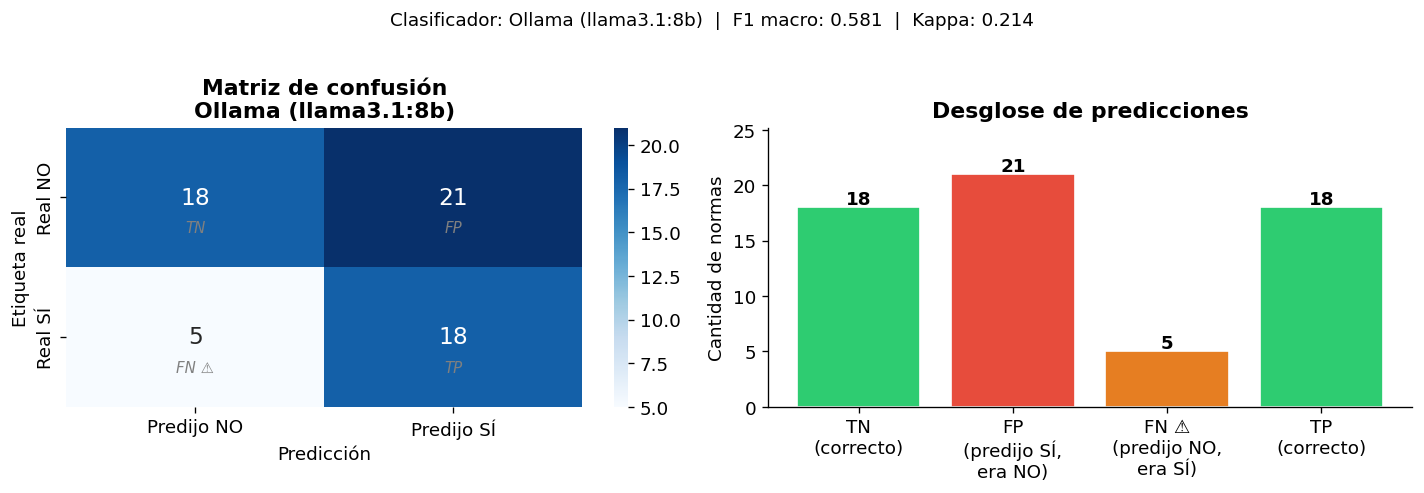

TN=18  FP=21  FN=5  TP=18
Total correctos: 36/62 (58.1%)
Total errores:   26/62 (41.9%)


In [7]:
cm = confusion_matrix(y_real, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Predijo NO', 'Predijo SÍ'],
    yticklabels=['Real NO', 'Real SÍ'],
    annot_kws={'size': 14}
)
ax.set_title(f'Matriz de confusión\n{NOMBRE_CLASIFICADOR}', fontweight='bold')
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción')
for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN ⚠'), ((1,1),'TP')]:
    ax.text(j+0.5, i+0.75, label, ha='center', fontsize=9, color='gray', style='italic')


ax2 = axes[1]
categorias = ['TN\n(correcto)', 'FP\n(predijo SÍ,\nera NO)', 'FN ⚠\n(predijo NO,\nera SÍ)', 'TP\n(correcto)']
valores    = [tn, fp, fn, tp]
colores    = ['#2ecc71', '#e74c3c', '#e67e22', '#2ecc71']
bars = ax2.bar(categorias, valores, color=colores, edgecolor='white')
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')
ax2.set_title('Desglose de predicciones', fontweight='bold')
ax2.set_ylabel('Cantidad de normas')
ax2.set_ylim(0, max(valores) * 1.2)

n = len(merged)
plt.suptitle(f'Clasificador: {NOMBRE_CLASIFICADOR}  |  F1 macro: {metricas["F1 macro"]:.3f}  |  Kappa: {metricas["Kappa"]:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Total correctos: {tn+tp}/{n} ({(tn+tp)/n:.1%})')
print(f'Total errores:   {fp+fn}/{n} ({(fp+fn)/n:.1%})')

## 6. Análisis de errores

Se muestran primero los **falsos negativos** (predijo NO, era SÍ) porque son más costosos.

In [8]:
errores = merged[merged['caso_ok_pred'] != merged['caso_ok_real']].copy()
errores['tipo_error'] = errores.apply(
    lambda r: 'FN — predijo NO, era SÍ' if r['caso_ok_pred'] == 0
              else 'FP — predijo SÍ, era NO',
    axis=1
)

print(f'Total errores: {len(errores)} de {n} ({len(errores)/n:.1%})')
print(errores['tipo_error'].value_counts().to_string())

Total errores: 26 de 62 (41.9%)
tipo_error
FP — predijo SÍ, era NO    21
FN — predijo NO, era SÍ     5


In [9]:
# ── Falsos negativos ──────────────────────────────────────────────────────────
fn_df = errores[errores['tipo_error'] == 'FN — predijo NO, era SÍ']

print(f'⚠️  Falsos negativos: {len(fn_df)} casos')
print('(El clasificador dijo NO pero la etiqueta real era SÍ)')
print()

cols = ['Número', 'Título'] if 'Título' in fn_df.columns else ['Número']
if 'Justificación' in fn_df.columns:
    cols.append('Justificación')

pd.set_option('display.max_colwidth', 80)
display(fn_df[cols].reset_index(drop=True))

⚠️  Falsos negativos: 5 casos
(El clasificador dijo NO pero la etiqueta real era SÍ)



,Número,Título,Justificación
0,13116,ACCIDENTE DE AVIACION,0: La norma otorga pensiones y beneficios económicos a familiares de víctima...
1,888,DUELO NACIONAL,0: La norma se limita a declarar un día de Duelo Nacional y no establece mec...
2,1800,ACUERDOS,0: La norma aprueba un Acuerdo de Solución Amistosa que implícitamente compr...
3,840,DUELO NACIONAL,"0: La norma declara un día de Duelo Nacional, pero no establece derechos, ga..."
4,490,MONUMENTOS NACIONALES,0: La norma se dirige principalmente a la creación de un monumento en memori...


In [10]:
# ── Falsos positivos ──────────────────────────────────────────────────────────
fp_df = errores[errores['tipo_error'] == 'FP — predijo SÍ, era NO']

print(f'Falsos positivos: {len(fp_df)} casos')
print('(El clasificador dijo SÍ pero la etiqueta real era NO)')
print()

cols = ['Número', 'Título'] if 'Título' in fp_df.columns else ['Número']
if 'Justificación' in fp_df.columns:
    cols.append('Justificación')

display(fp_df[cols].reset_index(drop=True))

Falsos positivos: 21 casos
(El clasificador dijo SÍ pero la etiqueta real era NO)



,Número,Título,Justificación
0,26004,ACUERDOS,1: La norma establece la asistencia jurídica para medidas asegurativas e ind...
1,844,FONDO DE ASISTENCIA DIRECTA A VICTIMAS DE TRATA,1: La norma establece asistencia directa a víctimas de trata y explotación d...
2,235,PROTECCION CONTRA LA VIOLENCIA FAMILIAR,1: La norma establece una serie de derechos y garantías para las víctimas de...
3,25742,CODIGO PENAL,1: La norma establece un beneficio para las víctimas en términos de decomiso...
4,26378,CONVENCIONES,1: La norma establece obligaciones a los Estados Parte para proteger y recup...
5,26842,PREVENCION Y SANCION DE LA TRATA DE PERSONAS Y ASISTENCIA A SUS VICTIMAS,1: La norma establece garantías específicas y derechos para las víctimas de ...
6,27508,FONDO FIDUCIARIO PUBLICO,1: La norma establece la creación de un fondo fiduciario público destinado a...
7,25616,PROTOCOLOS,1: La norma establece asistencia y cooperación para la rehabilitación y rein...
8,26827,DERECHOS HUMANOS,1: La norma crea un sistema de prevención y protección contra torturas y tra...
9,25112,CONVENCIONES,1: La norma establece asistencia para el cuidado y rehabilitación de víctima...
